Dans ce projet, nous avons choisi d’utiliser deux jeux de données afin d’évaluer la robustesse et la généralisabilité des modèles étudiés, notamment les Reinforcement Learning Trees (RLT). L’utilisation d’un seul dataset ne permettrait pas de vérifier si les performances observées sont propres à un contexte particulier ou si elles se maintiennent dans des situations variées. Nous avons ainsi retenu le dataset Breast Cancer Wisconsin (Diagnostic), qui correspond à un problème de classification médicale avec 30 variables numériques, et le dataset Wine Quality, qui relève d’un problème de régression dans le domaine agroalimentaire avec une structure de données plus simple et un nombre de variables réduit. Ces deux datasets se complètent parfaitement : ils diffèrent par leur nature (classification vs régression), leur domaine d’application (santé vs industrie), leur dimensionnalité et leur taille. Ce contraste permet d’examiner le comportement de RLT et des modèles comparatifs dans des environnements hétérogènes, renforçant ainsi la pertinence et la portée des conclusions obtenues.

Dans ce notebook, on va étudier le dataset (wine quality):

# Phase 1 : Business Understanding

### Business Objectif 1 : Améliorer la cohérence et la rapidité de l’évaluation de la qualité des vins

L’évaluation de la qualité des vins repose encore largement sur l’avis de dégustateurs humains, ce qui peut entraîner des résultats variables d’un expert à l’autre et rendre le processus long et coûteux. L’objectif ici est de disposer d’un outil capable d’estimer automatiquement la qualité d’un vin à partir de mesures physico-chimiques simples. Un tel système permettrait d’obtenir une analyse plus rapide et plus uniforme, tout en réduisant la dépendance aux jugements subjectifs. Cela faciliterait le travail des équipes de contrôle qualité et améliorerait la cohérence des évaluations

### Business Objectif 2 : Aider les producteurs à prendre les bonnes décisions tout au long de la production

La qualité finale d’un vin dépend de nombreux choix effectués pendant la production : durée de fermentation, assemblages, traitements, etc. Pouvoir prédire la qualité future d’un vin grâce à un modèle automatique donnerait aux producteurs une vision plus claire dès les premières étapes du processus. Cela leur permettrait d’adapter leurs décisions techniques au bon moment et de concentrer leurs efforts sur les cuvées les plus prometteuses. L’objectif est donc d’améliorer l’efficacité globale de la production en évitant du gaspillage et en valorisant plus rapidement les vins de meilleure qualité.

### Data Science Objective 1 : Construire un modèle capable d’estimer la qualité d’un vin :

Développer un modèle de régression qui puisse prédire la note de qualité d’un vin à partir de ses caractéristiques physico-chimiques. L’idée est de reproduire au mieux l’avis d’un expert, mais de manière plus rapide et plus cohérente. Ce modèle doit permettre d’évaluer automatiquement un vin sans passer par une dégustation systématique, ce qui constitue un gain de temps important pour les producteurs et les équipes de contrôle qualité.

### Data Science Objective 2 : Comprendre ce qui influence réellement la qualité d’un vin :

Identifier les facteurs physico-chimiques qui influencent le plus la qualité d’un vin afin d’aider les producteurs à mieux comprendre et optimiser leur processus de production.

# Phase 2 : Data Understanding

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [5]:
wine = pd.read_csv("WineDT.csv")

In [6]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [7]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
wine.shape

(1143, 13)

In [9]:
wine = wine.drop("Id", axis=1)

In [10]:
print("\nValeurs manquantes :")
wine.isnull().sum()


Valeurs manquantes :


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [11]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


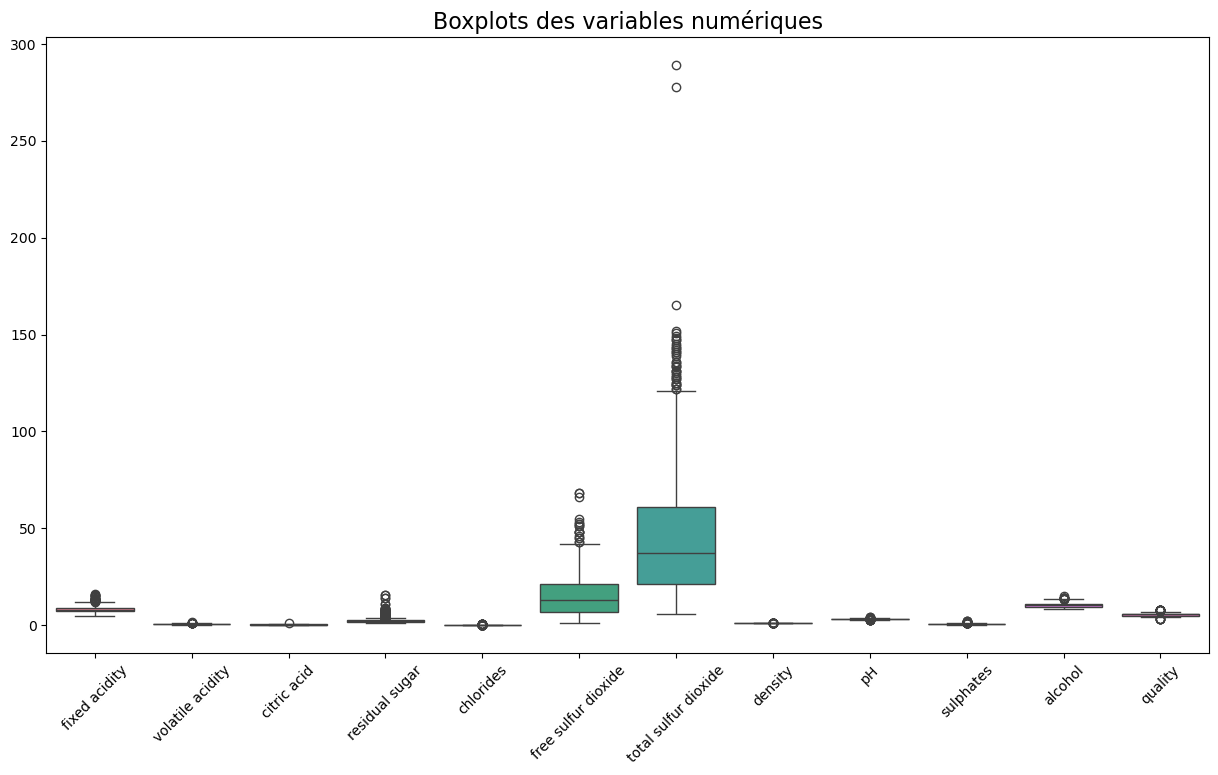

In [12]:
plt.figure(figsize=(15, 8))
sns.boxplot(data =wine)
plt.title("Boxplots des variables numériques", fontsize=16)
plt.xticks(rotation=45)
plt.show()


#### Interprétation :

Les boxplots montrent que certaines variables, surtout free et total sulfur dioxide, contiennent beaucoup de valeurs aberrantes. Les autres variables sont globalement plus stables.

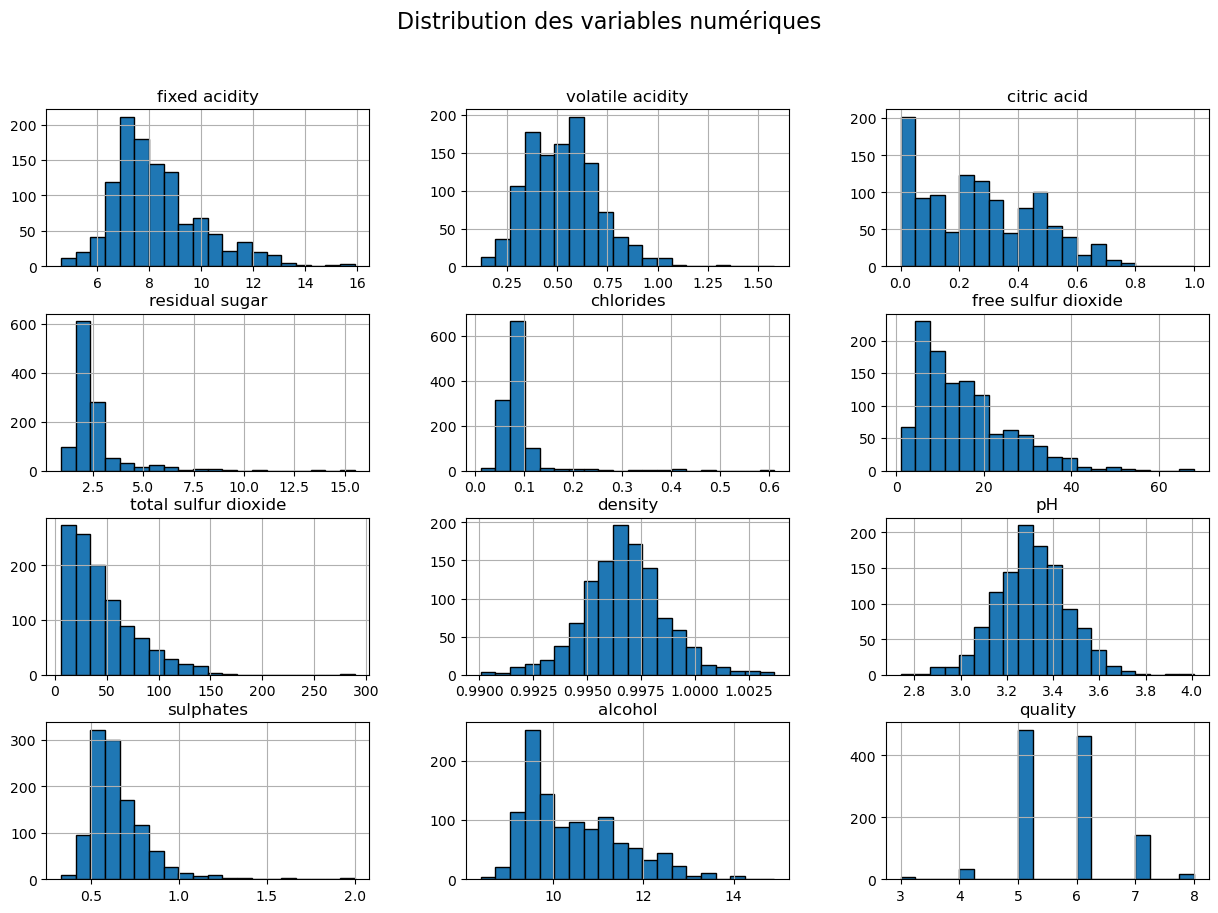

In [13]:
wine.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distribution des variables numériques", fontsize=16)
plt.show()


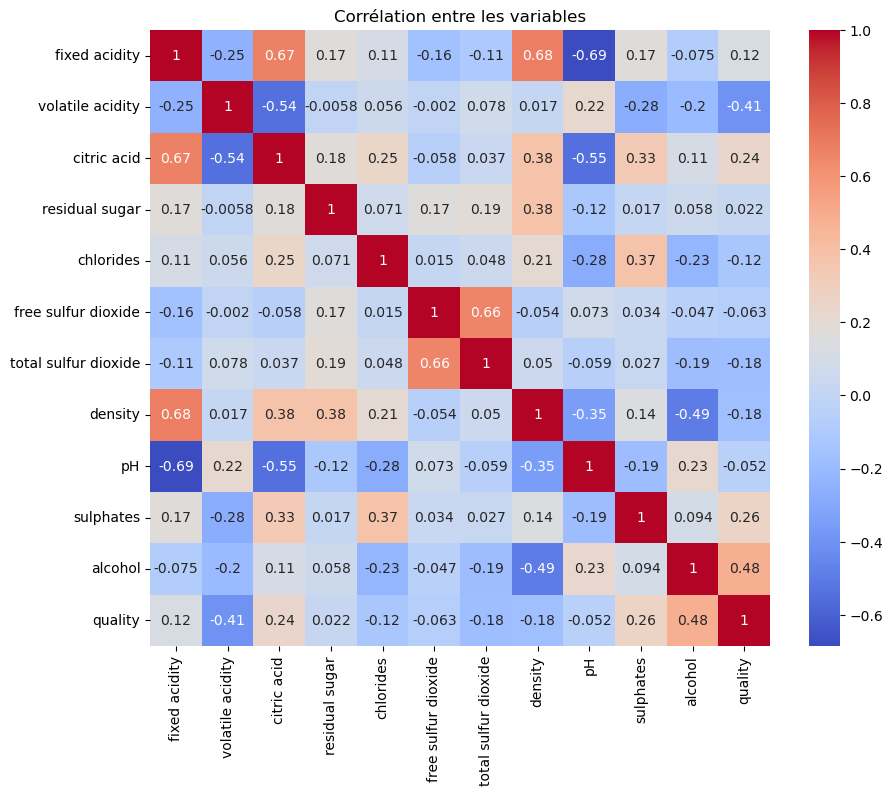

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(wine.corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()

#### Interprétation:
On observe une corrélation positive importante entre l’alcool (0.48) et la qualité : plus le vin est alcoolisé, meilleure est sa qualité. Par contre, l’acidité volatile (-0.39) est négativement corrélée, indiquant qu’un excès d’acidité volatile réduit la qualité. Les sulfates (0.25) et l’acide citrique (0.23) contribuent faiblement à une meilleure qualité ( corrélation moyenne ), tandis que la densité (-0.17) a un effet inverse. Les autres variables présentent des corrélations faibles, ce qui montre qu’elles n'influent pas la qualité du vin.


C:\Users\Dr.Console\AppData\Local\Temp\ipykernel_13672\4008349086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=wine, palette='coolwarm')


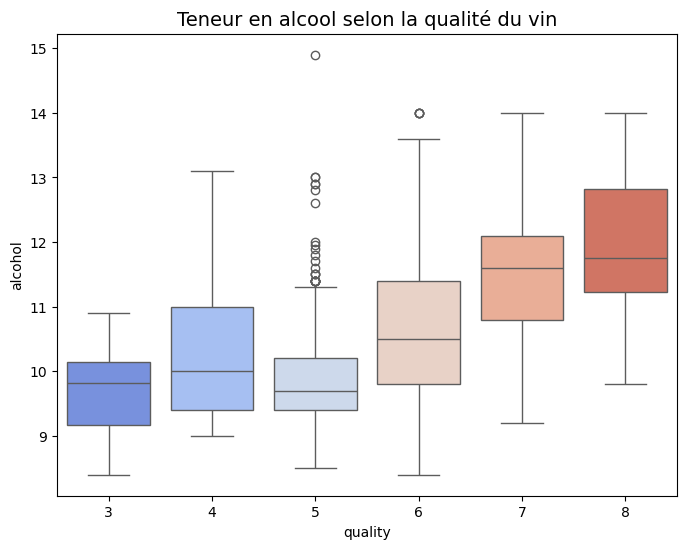

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='quality', y='alcohol', data=wine, palette='coolwarm')
plt.title("Teneur en alcool selon la qualité du vin", fontsize=14)
plt.show()

#### Interprétation :

La teneur en alcool augmente globalement avec la qualité du vin.
Les vins de qualité élevée (7–8) présentent des niveaux d’alcool plus élevés et plus dispersés, tandis que les vins de faible qualité (3–5) ont des valeurs plus basses et plus resserrées. Cela indique que l’alcool est un facteur potentiellement important pour distinguer la qualité.

In [16]:
# Filtrer les vins de qualité 5
wine_q5 = wine[wine['quality'] == 5]

# Calculer les bornes de détection des valeurs aberrantes (méthode IQR)
Q1 = wine_q5['alcohol'].quantile(0.25)
Q3 = wine_q5['alcohol'].quantile(0.75)
IQR = Q3 - Q1
borne_sup = Q3 + 1.5 * IQR
borne_inf = Q1 - 1.5 * IQR

# Identifier les valeurs aberrantes
outliers_q5 = wine_q5[(wine_q5['alcohol'] > borne_sup) | (wine_q5['alcohol'] < borne_inf)]

print(f"Bornes de détection pour qualité=5 : [{borne_inf:.2f}, {borne_sup:.2f}]")
print(f"Nombre de valeurs aberrantes : {outliers_q5.shape[0]}")
outliers_q5[['alcohol', 'quality']].head()

Bornes de détection pour qualité=5 : [8.20, 11.40]
Nombre de valeurs aberrantes : 24


,alcohol,quality
91,13.0,5
233,11.5,5
248,13.0,5
396,11.5,5
401,11.4,5


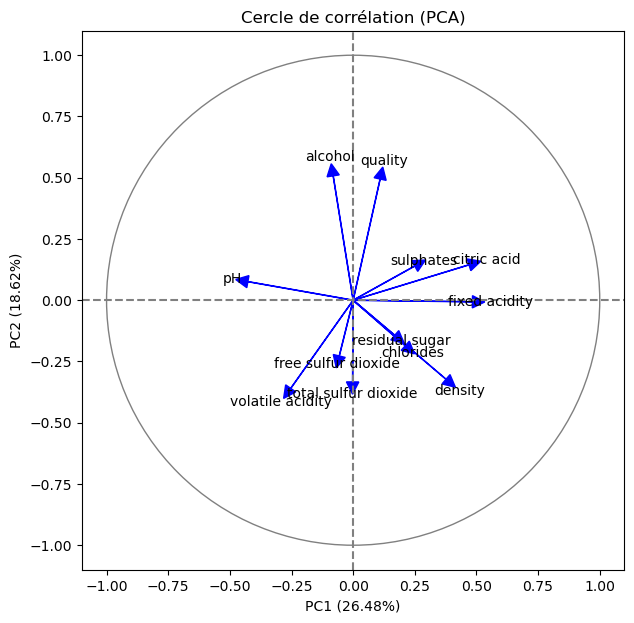

In [17]:
X = wine.select_dtypes(include=['float64', 'int64'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pcs = pca.components_

plt.figure(figsize=(7,7))

for i, var in enumerate(X.columns):
    plt.arrow(0, 0,
              pcs[0, i], pcs[1, i],
              head_width=0.05, head_length=0.05, color='blue')
    plt.text(pcs[0, i]*1.15, pcs[1, i]*1.15, var, color='black',
             ha='center', va='center')

circle = plt.Circle((0, 0), 1, color='gray', fill=False)
plt.gca().add_artist(circle)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.xlabel(f"PC1 ({round(pca.explained_variance_ratio_[0]*100, 2)}%)")
plt.ylabel(f"PC2 ({round(pca.explained_variance_ratio_[1]*100, 2)}%)")
plt.title("Cercle de corrélation (PCA)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(False)
plt.show()

#### Interprétation
On observe que l’alcool, la qualité et les sulphates sont les variables les plus liées au premier axe de la PCA. Elles expliquent donc une partie importante de la variabilité du dataset.
À l’inverse, des variables comme la densité ou l’acidité volatile vont dans une direction opposée, ce qui montre une relation inverse avec ces premières variables.
Les flèches proches indiquent des variables liées, tandis que les directions opposées montrent des comportements contraires.

In [18]:
loadings = pca.components_.T
contrib = (loadings**2)
contrib = contrib / contrib.sum(axis=0)
contrib = contrib * 100

contrib_df = pd.DataFrame(contrib,
                          index=X.columns,
                          columns=['PC1', 'PC2'])

print(" Tableau des contributions (%)")
print(contrib_df.round(2))

 Tableau des contributions (%)
                        PC1    PC2
fixed acidity         23.39   0.00
volatile acidity       6.41  12.95
citric acid           22.07   2.09
residual sugar         2.85   2.05
chlorides              4.46   3.45
free sulfur dioxide    0.32   5.18
total sulfur dioxide   0.00  11.12
density               14.19  10.41
pH                    18.23   0.57
sulphates              6.23   1.95
alcohol                0.66  25.77
quality                1.20  24.47


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


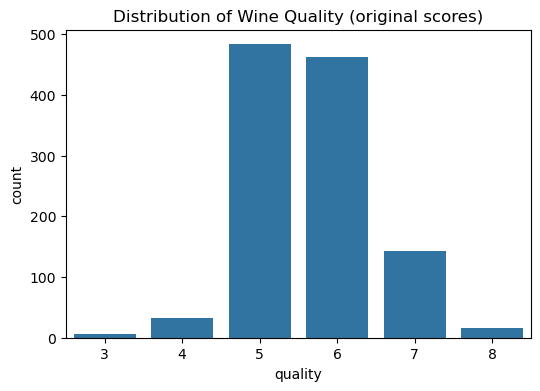

Counts (good=1):
quality_label
0    984
1    159
Name: count, dtype: int64


In [19]:
display(wine.describe())

# Distribution of quality
plt.figure(figsize=(6,4))
sns.countplot(x='quality', data=wine)
plt.title('Distribution of Wine Quality (original scores)')
plt.show()

# Binary target for classification
wine['quality_label'] = (wine['quality'] >= 7).astype(int)  # 1 -> good, 0 -> not good
print('Counts (good=1):')
print(wine['quality_label'].value_counts())

#### Interprétation :

La distribution est déséquilibrée : la grande majorité des vins ont une qualité 5 ou 6, tandis que les notes extrêmes (3, 4, 8) sont très rares. Cela montre que le dataset est principalement composé de vins de qualité moyenne.

# Phase 3: Data Preperation

In [20]:
scaler = StandardScaler()
wine_scaled =wine.copy()
wine_scaled[wine.select_dtypes(include='number').columns] = scaler.fit_transform(wine.select_dtypes(include='number'))


In [23]:
#Min-Max Scaling
scaler = MinMaxScaler()
wine_scaled =wine.copy()
wine_scaled[wine.select_dtypes(include='number').columns] = scaler.fit_transform(wine.select_dtypes(include='number'))

In [26]:
X =wine_scaled.drop(columns=['quality'])
y = wine['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
